# Каталог «Своего Вина»: что нам выдали и с чем придётся работать

Хакатон начался 15.09.2026. Организаторы передали дамп каталога (`data/strapi_output0709.csv`),
медиа-папку Strapi (`data/uploads/`) и скрипт оценки с тремя публичными кадрами (`data/eval/`).
Ноутбук отвечает на вопросы, без которых нельзя ни собрать индекс, ни понять, где нас ждут ошибки:

1. Что в дампе: сколько вин, какие поля, где дыры.
2. Близнецы по метаданным — то, о чём прямо предупреждает ТЗ («у одной серии отличается сезон, год или категория при одинаковой этикетке»).
3. Как дамп ложится на `uploads` — ключа между ними нет, связь восстановлена по имени.
4. Что такое эталон физически: размер, прозрачный фон, доля мелких.
5. С каким фоном индексировать вырезки — маленький эксперимент, который решает вопрос до сборки.
6. Как детектор этикетки ведёт себя на студийных вырезках, а не на фото полки.
7. Близнецы по картинке: кто в каталоге неотличим от соседа для DINOv2.
8. Публичные кадры eval: что в них есть и чего нет в каталоге.
9. Выводы.

Цифры считаются заново при каждом запуске; тяжёлые результаты (кропы, векторы) кэшируются в `models/`.
Перед разделами 5–8 нужны веса детектора (`models/label_detector.pt`), перед 7 — собранный индекс
`models/index_platform` (`uv run python scripts/build_index.py --catalog platform --detect cascade --fit pad --out models/index_platform`).

In [1]:
import os, re, json, sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageDraw
from pillow_heif import register_heif_opener

register_heif_opener()  # свои эталоны в data/own сняты на iPhone, это HEIC

# Ноутбук лежит в notebooks/, а пути в коде проекта — от корня репозитория.
if not Path("data").exists():
    os.chdir("..")
assert Path("data/strapi_output0709.csv").exists(), "запускать из корня репозитория"

from wine_scanner.catalog import (
    load_platform_dump, index_uploads, strapi_key, vintage_from_name, load_eval_queries,
)

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
CATALOG = Path("data/catalog")

## 1. Дамп каталога

`strapi_output0709.csv` — выгрузка из Strapi от 07.09. Первое, что бросается в глаза: каждая строка
встречается дважды. Это артефакт экспорта, а не два вина, — `load_platform_dump` снимает точные дубли
и проверяет, что после этого slug уникален.

In [2]:
raw = pd.read_csv("data/strapi_output0709.csv")
dump = load_platform_dump()
print(f"строк в файле: {len(raw)}, точных дублей: {raw.duplicated().sum()}, уникальных slug: {len(dump)}")
print("\nпропуски по колонкам:")
print(dump.isna().sum().to_string())
dump.head(3)

строк в файле: 4147, точных дублей: 2044, уникальных slug: 2103

пропуски по колонкам:
name           0
category       0
color          0
region         0
grapes         2
description    0
winery         0
slug           0
photo_name     0


,name,category,color,region,grapes,description,winery,slug,photo_name
0,Автохтонное Вино Крыма белое сухое,Белое,Светло-соломенный,Крым,"Алиготе, Кокур Белый, Сары Пандас","В аромате присутствует фруктово-цветочное направление, к...",Валерий Захарьин,avtohtonnoe-vino-kryma-beloe-suhoe,PUSjv7dnMNilH25TO9BcbFN55lPrHsK4eSLja8tm9Ur62n50PyxhlRO1...
1,"Алиготе Баррель, 2024",Белое,Золотистый,Крым,Алиготе,"Вино золотистого цвета с тонкой структурой, хорошей кисл...",Коммуналка,aligote-barrel-2024,DSC09173.webp
2,ЗБ вайн СПУМАНТЕ Брют белое,Белое,соломенный,Крым,Алиготе,"Изысканный букет цитрусовых, с легким нюансом аромата ве...",Золотая Балка,zb-vajn-spumante-bryut-beloe,Спуманте белый брют.webp


топ-20 виноделен покрывают 50% каталога; виноделен с одним вином: 7


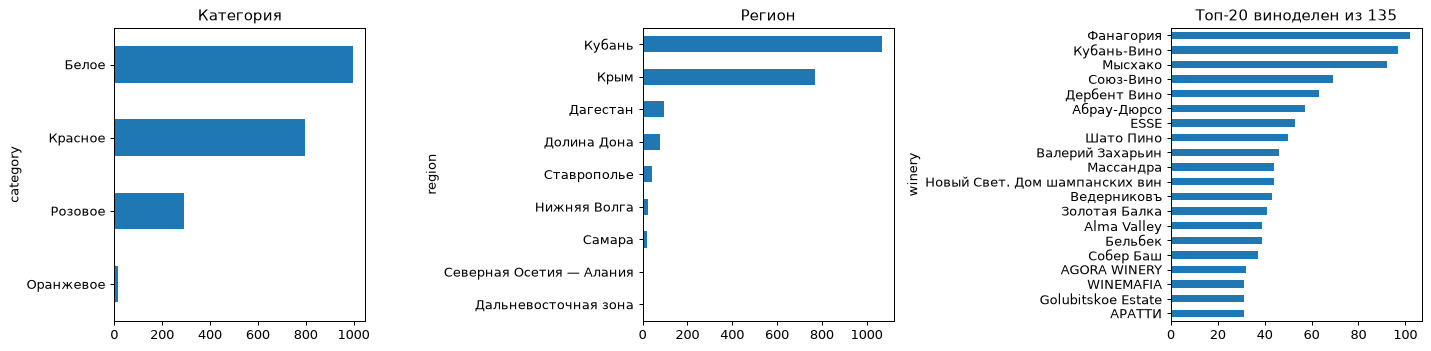

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
dump["category"].value_counts().plot.barh(ax=axes[0], title="Категория")
dump["region"].value_counts().plot.barh(ax=axes[1], title="Регион")
top = dump["winery"].value_counts()
top.head(20).plot.barh(ax=axes[2], title=f"Топ-20 виноделен из {top.size}")
for ax in axes: ax.invert_yaxis()
plt.tight_layout()
share_top20 = top.head(20).sum() / len(dump)
print(f"топ-20 виноделен покрывают {share_top20:.0%} каталога; виноделен с одним вином: {(top == 1).sum()}")

Хвост длинный: треть виноделен представлена одним-двумя винами, а два десятка крупных дают половину
каталога. Для поиска это значит, что ошибки будут сосредоточены внутри больших линеек — Фанагория,
Кубань-Вино, Мысхако, — где десятки вин одного дизайна.

Текст нам нужен под OCR-ветку: она ищет распознанные с этикетки слова по названию, винодельне и сортам.
Смотрим, на каком языке названия и что вообще есть в описаниях.

In [4]:
def script_of(text: str) -> str:
    cyr = len(re.findall(r"[А-Яа-яЁё]", text)); lat = len(re.findall(r"[A-Za-z]", text))
    if cyr and lat: return "смешанное"
    return "кириллица" if cyr else ("латиница" if lat else "без букв")

dump["name_script"] = dump["name"].map(script_of)
print(dump["name_script"].value_counts().to_string())
print(f"\nдлина описания, символов: медиана {dump['description'].str.len().median():.0f}, "
      f"p10 {dump['description'].str.len().quantile(.1):.0f}, p90 {dump['description'].str.len().quantile(.9):.0f}")
print(f"названий, повторяющихся у разных slug: {dump['name'].duplicated(keep=False).sum()} "
      f"(например: {', '.join(dump['name'].value_counts().head(5).index)})")

name_script
кириллица    1398
латиница      402
смешанное     303

длина описания, символов: медиана 190, p10 106, p90 372
названий, повторяющихся у разных slug: 444 (например: Рислинг, Пино Нуар, Каберне Совиньон, Совиньон Блан, Шардоне)


## 2. Близнецы по метаданным

ТЗ: «В каталоге много near-duplicates: у одной серии отличается сезон, год или категория при одинаковой
этикетке. Именно они — главный источник ошибок». Прежде чем смотреть на картинки, посчитаем, сколько
таких пар видно уже из таблицы.

Три уровня, от строгого к широкому:

- **семья по году** — slug'и, различающиеся только годом (`aligote-barrel-2024` / `-2023`);
- **семья по названию и винодельне** — одно и то же название у одной винодельни (то, что в ТЗ названо «сезон или категория»);
- **общее фото** — разные slug, у которых в дампе одно и то же имя файла. Такие по картинке неразличимы в принципе.

In [5]:
dump["vintage"] = [vintage_from_name(n, s) for n, s in zip(dump["name"], dump["slug"])]
dump["slug_base"] = dump["slug"].str.replace(r"-20[0-3]\d$", "", regex=True)
dump["name_base"] = (dump["name"].str.lower()
                     .str.replace(r"[,\s]*20[0-3]\d", "", regex=True).str.replace(r"\s+", " ", regex=True).str.strip())

year_family = dump.groupby("slug_base")["slug"].transform("size")
name_family = dump.groupby(["winery", "name_base"])["slug"].transform("size")
dump["shared_photo"] = dump["photo_name"].duplicated(keep=False)

print(f"slug с годом: {dump['vintage'].notna().sum()}")
print(f"семьи по году (>1 slug): {(dump[year_family > 1].groupby('slug_base').ngroups)} семей, {int((year_family > 1).sum())} slug")
print(f"семьи по названию+винодельне: {dump[name_family > 1].groupby(['winery','name_base']).ngroups} семей, {int((name_family > 1).sum())} slug")
print(f"slug с общим именем фото в дампе: {int(dump['shared_photo'].sum())}")
print("\nгоды в каталоге:", dump["vintage"].value_counts().sort_index().to_dict())

slug с годом: 116
семьи по году (>1 slug): 11 семей, 23 slug
семьи по названию+винодельне: 90 семей, 196 slug
slug с общим именем фото в дампе: 26

годы в каталоге: {2014.0: 3, 2015.0: 2, 2016.0: 2, 2017.0: 4, 2018.0: 3, 2019.0: 7, 2020.0: 14, 2021.0: 13, 2022.0: 20, 2023.0: 19, 2024.0: 20, 2025.0: 8, 2026.0: 1}


In [6]:
print("Семьи по году:")
display(dump[year_family > 1].sort_values("slug")[["slug", "name", "winery", "vintage"]].head(24))
print("\nSlug с общим именем фото в дампе:")
display(dump[dump["shared_photo"]].sort_values("photo_name")[["slug", "name", "winery", "photo_name"]])

Семьи по году:


,slug,name,winery,vintage
1,aligote-barrel-2024,"Алиготе Баррель, 2024",Коммуналка,2024.0
675,aligote-barrel-2025,"Алиготе Баррель, 2025",Коммуналка,2025.0
91,amelia,"Amelia, 2022",WINEMAFIA,2022.0
92,amelia-2023,"Amelia, 2023",WINEMAFIA,2023.0
151,cabernet-franc-pinot-noir-2021,Cabernet Franc-Pinot Noir 2021,Vibes,2021.0
152,cabernet-franc-pinot-noir-2022,Cabernet Franc-Pinot Noir 2022,Vibes,2022.0
215,david,"David, 2020",WINEMAFIA,2020.0
216,david-2021,"David, 2021",WINEMAFIA,2021.0
217,david-2022,"David, 2022",WINEMAFIA,2022.0
1152,kokur-suhoe,Кокур сухое,Массандра,NaN



Slug с общим именем фото в дампе:


,slug,name,winery,photo_name
602,vibes-silvaner-barrel-fermented-2022,"VIBES, Silvaner Barrel Fermented 2022",Vibes,03-Silvaner-2022-Barrel-Fermented.webp
604,vibes-vermentino-viognier-barrel-fermented-2022,"Vibes, Vermentino-Viognier Barrel Fermented 2022",Vibes,03-Silvaner-2022-Barrel-Fermented.webp
674,aligote-avtorskoe,Алиготе Авторское,Массандра,4285_eqF1Fau-no-bg-preview (carve.photos).webp
677,aligote-avtorskoe-vino,Алиготе. Авторское вино,Массандра,4285_eqF1Fau-no-bg-preview (carve.photos).webp
1372,novyj-svet-vyderzhannoe-bryut,Новый Свет выдержанное брют,Новый Свет. Дом шампанских вин,4300_tlKHpEg.webp
1374,novyj-svet-polusladkoe,Новый Свет полусладкое,Новый Свет. Дом шампанских вин,4300_tlKHpEg.webp
1493,pino-nuar-2025,"Пино Нуар, 2025",Винодельня Братьев Мельниковых,DSC00836.webp
377,method-classic-kokur,Method Classic Кокур,Винодельня Братьев Мельниковых,DSC00836.webp
1154,kokur-2025,"Кокур, 2025",Винодельня Братьев Мельниковых,DSC00839-Photoroom.webp
1153,kokur-suhoe-2025,"Кокур Сухое, 2025",Винодельня Братьев Мельниковых,DSC00839-Photoroom.webp


Что из этого следует. Семей «то же вино, другой год» в каталоге немного — два десятка slug, — и годом
они отличаются буквально одной строкой на этикетке. Наш блок Э8 (чтение года) сделан ровно под это.
А вот семьи «то же название у той же винодельни» шире: там и разный объём (0.75 / 0.7), и разные
категории одной линейки, и просто повторные карточки. Часть из них по картинке одинакова — это увидим в разделе 7.

Общее имя фото в дампе ещё не значит общую картинку: часть таких пар после разбора uploads разошлась
по разным файлам (одно имя загружали дважды с разным содержимым). Настоящий список неразличимых —
по хэшу файла, он ниже в разделе 3: на таких slug система будет ошибаться в половине случаев при любом
качестве модели, и это надо знать заранее, чтобы не искать ошибку в пайплайне.

## 3. Как дамп ложится на uploads

В дампе у карточки записано человеческое имя файла — «Поместье Голубицкое Рислинг.webp». В `uploads`
тот же файл лежит как `Pomeste_Golubiczkoe_Risling_02c2e84311.webp`: Strapi транслитерирует имя по
своей таблице (ц→cz, й→j, х→h) и приписывает хэш. Прямого ключа нет, поэтому `scripts/build_catalog.py`
восстанавливает связь по имени, а неоднозначности снимает сравнением байтов и, в остатке, страницей вина на сайте.

Результат лежит в `data/catalog/catalog.csv`; здесь только проверяем, что покрытие полное, и смотрим на остаток.

In [7]:
catalog = pd.read_csv(CATALOG / "catalog.csv", dtype={"vintage": "Int64"})
uploads = index_uploads()
print(f"оригиналов в uploads: {sum(map(len, uploads.values()))}, из них с уникальным ключом: {sum(len(v) == 1 for v in uploads.values())}")
print("\nкак сопоставилось:")
print(catalog["match"].value_counts().to_string())
print(f"\nкартинок на диске: {len(list((CATALOG / 'images').glob('*.png')))} из {len(catalog)}")
unresolved = pd.read_csv(CATALOG / "unresolved.csv")
print(f"\nне разрешено ({len(unresolved)}): у этих вин нет страницы на сайте, а под одним именем лежит несколько"
      " загрузок одного и того же файла — взят первый:")
display(unresolved[["slug", "photo_name", "source_file"]])

shared = catalog[catalog["shared_image"]].sort_values("image_md5")
print(f"\nslug, чей эталон байт в байт совпадает с другим slug: {len(shared)} "
      f"(групп: {shared['image_md5'].nunique()}). По имени фото в дампе таких видно только {int(catalog['shared_photo'].sum())}.")
display(shared[["slug", "name", "winery", "image_md5"]].assign(image_md5=lambda d: d["image_md5"].str[:8]))

оригиналов в uploads: 6237, из них с уникальным ключом: 5073

как сопоставилось:
match
exact        2021
site           54
bytes          23
ambiguous       5

картинок на диске: 2103 из 2103

не разрешено (5): у этих вин нет страницы на сайте, а под одним именем лежит несколько загрузок одного и того же файла — взят первый:


,slug,photo_name,source_file
0,vibes-silvaner-barrel-fermented-2022,03-Silvaner-2022-Barrel-Fermented.webp,data/uploads/03_Silvaner_2022_Barrel_Fermented_01addc1e7...
1,polusladkoe-krasnoe-zb-vajn-frizzante,Фризанте красное полусладкое.webp,data/uploads/Frizante_krasnoe_polusladkoe_67706f9516.webp
2,polusladkoe-krasnoe-zolotaya-balka,Полусладкое красное.webp,data/uploads/Polusladkoe_krasnoe_09d1ac765c.webp
3,polusuhoe-rozovoe-zb-vajn-frizzante,ZB Frizzante Rose Semidry.webp,data/uploads/ZB_Frizzante_Rose_Semidry_7ffea30caf.webp
4,suhoe-beloe-zb-vajn-frizzante,Фризанте белое сухое.webp,data/uploads/Frizante_beloe_suhoe_1efeefdc54.webp



slug, чей эталон байт в байт совпадает с другим slug: 55 (групп: 27). По имени фото в дампе таких видно только 26.


,slug,name,winery,image_md5
1067,villa-urkusta-kaberne-sovinon-klassik-krasnoe-suhoe-12,Каберне совиньон Классик,Вилла Уркуста,0af9bc6c
1068,villa-urkusta-kaberne-sovinon-klassik-krasnoe-suhoe-139,Каберне совиньон Классик,Вилла Уркуста,0af9bc6c
276,agrolayn-heritage-dg-skin-contact-rkatsiteli-rkatsiteli-...,Heritage DG Skin contact Rkatsiteli,Агролайн,0be45eba
275,agrolayn-heritage-dg-skin-contact-red-saperavi-krasnoe-s...,Heritage Dg Skin Contact Red,Агролайн,0be45eba
1645,oxana-istratova-wine-rkatsiteli-2024-oranzhevoe-suhoe-12,Ркацители 2024,Oxana Istratova Wine,108ee28b
1644,oxana-istratova-wine-rkatsiteli-2023-oranzhevoe-suhoe-113,Ркацители 2023,Oxana Istratova Wine,108ee28b
414,esse-muskat-muskat-belyy-beloe-ekstra-bryut-115,Muskat,ESSE,21bd32d6
218,esse-demi-sec-muscat-nectar-muskat-belyy-beloe-ekstra-br...,Demi-Sec Muscat Nectar,ESSE,21bd32d6
857,oxana-istratova-wine-vione-2024-oranzhevoe-suhoe-13,Вионье 2024,Oxana Istratova Wine,28dcd095
856,oxana-istratova-wine-vione-2023-oranzhevoe-suhoe-119,Вионье 2023,Oxana Istratova Wine,28dcd095


## 4. Эталон как изображение

Это не фотографии, а вырезанные бутылки на прозрачном фоне — то, что показывается в карточке на сайте.
Для нас это означает две вещи: во-первых, фон под бутылкой мы выбираем сами (раздел 5); во-вторых,
у части карточек эталон крошечный, и этикетка на нём — считанные десятки пикселей.

         count    mean     std    min     25%     50%     75%     max
width   2103.0   762.0   798.0  116.0   271.0   336.0  1024.0  6337.0
height  2103.0  1739.0  1359.0  357.0  1000.0  1080.0  2000.0  9506.0

уже 200 px: 67, уже 300 px: 893, шире 1000 px: 528


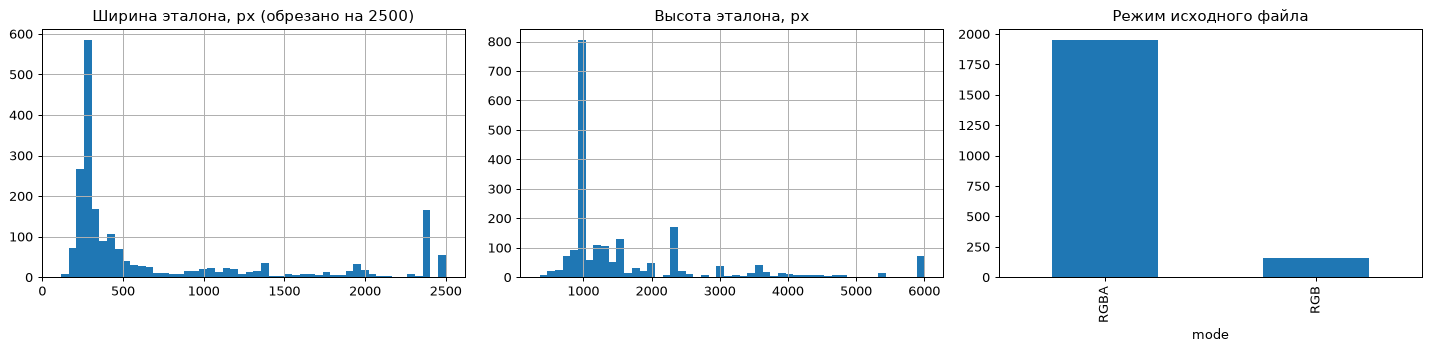

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
catalog["width"].clip(upper=2500).hist(bins=50, ax=axes[0]); axes[0].set_title("Ширина эталона, px (обрезано на 2500)")
catalog["height"].clip(upper=6000).hist(bins=50, ax=axes[1]); axes[1].set_title("Высота эталона, px")
catalog["mode"].value_counts().plot.bar(ax=axes[2], title="Режим исходного файла")
plt.tight_layout()
print(catalog[["width", "height"]].describe().round(0).T)
print(f"\nуже 200 px: {(catalog['width'] <= 200).sum()}, уже 300 px: {(catalog['width'] <= 300).sum()}, шире 1000 px: {(catalog['width'] > 1000).sum()}")

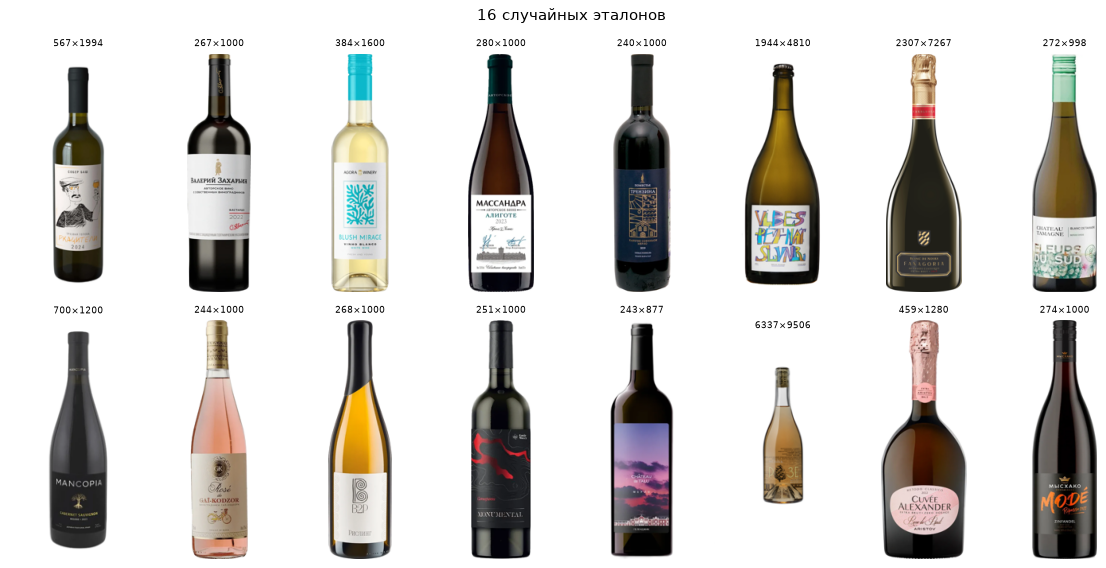

In [9]:
def gallery(paths, captions, columns=8, size=150, title=None):
    rows = (len(paths) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 1.6, rows * 3.2))
    for ax, path, caption in zip(np.ravel(axes), paths, captions):
        im = ImageOps.exif_transpose(Image.open(path)).convert("RGB"); im.thumbnail((size, size * 2))
        ax.imshow(im); ax.set_title(caption, fontsize=7); ax.axis("off")
    for ax in np.ravel(axes)[len(paths):]: ax.axis("off")
    if title: fig.suptitle(title)
    plt.tight_layout()

sample = catalog.sample(16, random_state=7)
gallery([CATALOG / "images" / f"{s}.png" for s in sample["slug"]],
        [f"{w}×{h}" for w, h in zip(sample["width"], sample["height"])], title="16 случайных эталонов")

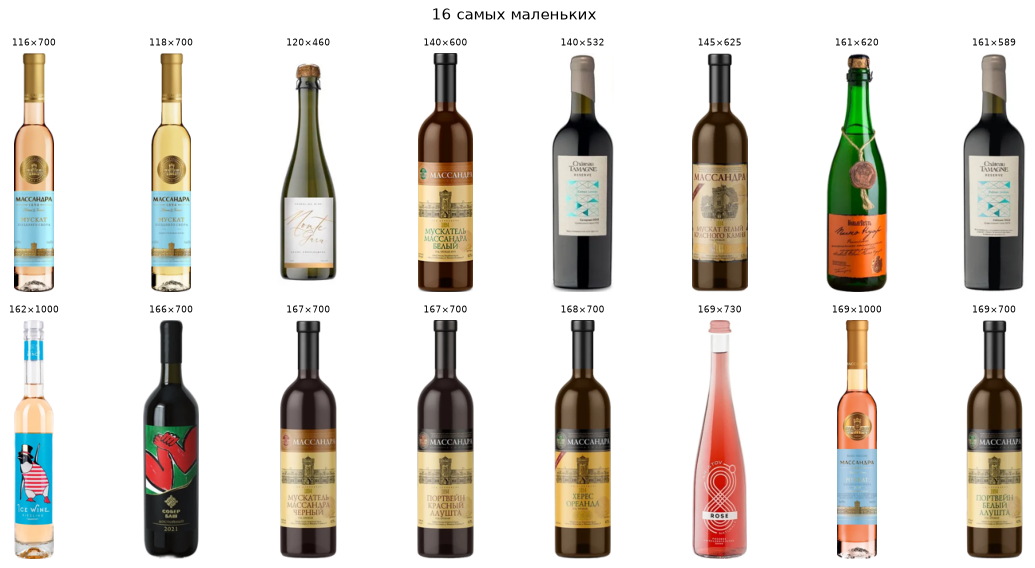

In [10]:
smallest = catalog.nsmallest(16, "width")
gallery([CATALOG / "images" / f"{s}.png" for s in smallest["slug"]],
        [f"{w}×{h}" for w, h in zip(smallest["width"], smallest["height"])], title="16 самых маленьких")

Для сравнения — наши собственные эталоны из `data/own`: снятые на телефон бутылки на столе. Разница
доменов очевидна глазами, и это важно помнить, читая старые метрики: все цифры до хакатона считались
на телефонных эталонах против телефонных же запросов, а теперь эталон студийный.

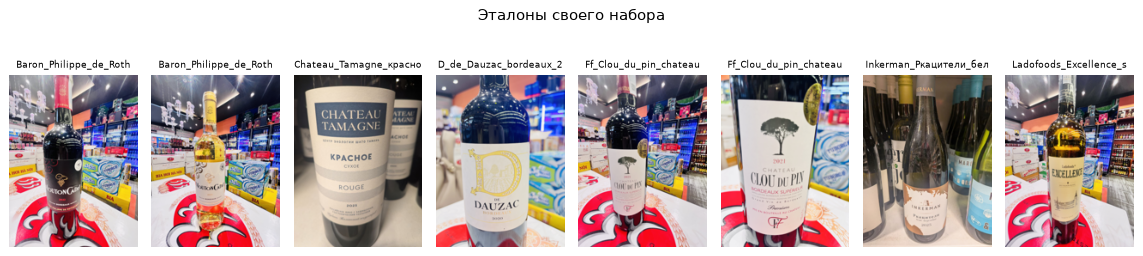

In [11]:
own = sorted(p for p in Path("data/own").glob("*/catalog.*"))[:8]
gallery(own, [p.parent.name[:22] for p in own], title="Эталоны своего набора")

## 5. С каким фоном индексировать

`Image.convert("RGB")` у PIL выбрасывает альфа-канал, и прозрачные пиксели становятся тем, что записано
в RGB под ними, — как правило чёрным. У эталона выше две трети площади прозрачны, и без вмешательства
каталог превратился бы в «бутылки на чёрном», чего на живых фотографиях не бывает.

Эксперимент маленький, но он решает вопрос до сборки индекса: берём единственный кадр eval, для которого
ответ известен (Мускатель Массандра белый), и сравниваем косинус DINOv2 между ним и его карточкой,
положенной на чёрный, белый и серый фон. Заодно смотрим, что на каждом варианте вырезает детектор.

/Users/irinamistulova/PycharmProjects/rshb_my_wine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/440 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 440/440 [00:00<00:00, 11348.36it/s]

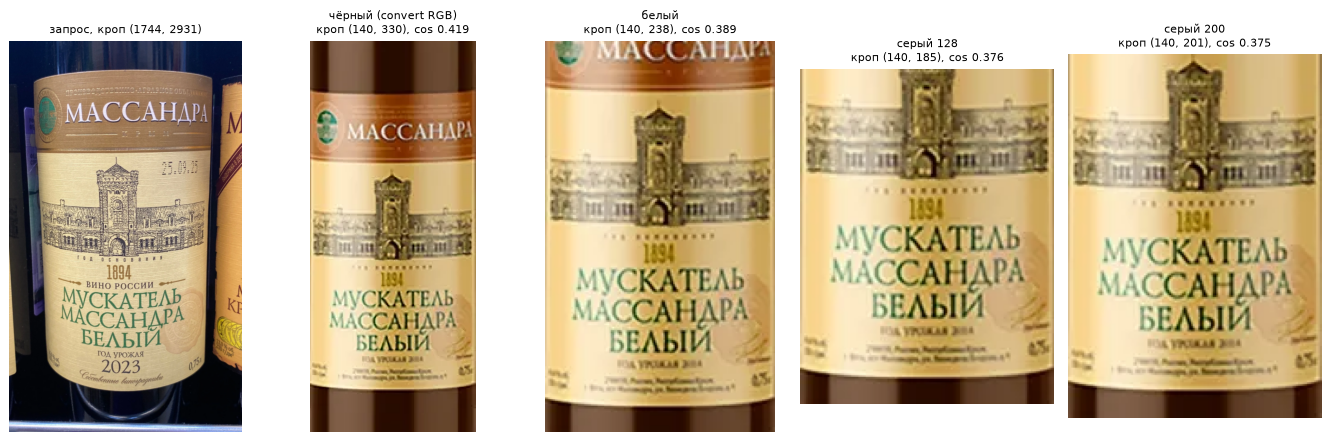

In [12]:
import torch
from wine_scanner.detect import BottleDetector, CascadeCropper
from wine_scanner.embed import Dinov2Embedder, load_image, pick_device

device = pick_device()
cascade = CascadeCropper(BottleDetector(device=device, mode="bottle"),
                         BottleDetector(device=device, weights_path=Path("models/label_detector.pt")))
embedder = Dinov2Embedder(device=device, fit="pad")

def embed(image):
    return embedder.encode_image(image).cpu().numpy().ravel()

MASSANDRA = "massandra-muskatel-belyy-belye-sorta-vinograda-beloe-sladkoe-16"
source = Path(catalog.set_index("slug").loc[MASSANDRA, "source_file"])
rgba = ImageOps.exif_transpose(Image.open(source)).convert("RGBA")
query = load_image("data/eval/queries/02eef911.webp")
query_crop = cascade.crop(query)
q = embed(query_crop)

def on_background(rgba, color):
    canvas = Image.new("RGB", rgba.size, color); canvas.paste(rgba, mask=rgba.getchannel("A")); return canvas

variants = {"чёрный (convert RGB)": rgba.convert("RGB"), "белый": on_background(rgba, (255, 255, 255)),
            "серый 128": on_background(rgba, (128, 128, 128)), "серый 200": on_background(rgba, (200, 200, 200))}
fig, axes = plt.subplots(1, len(variants) + 1, figsize=(15, 5))
axes[0].imshow(query_crop); axes[0].set_title(f"запрос, кроп {query_crop.size}", fontsize=9); axes[0].axis("off")
for ax, (name, image) in zip(axes[1:], variants.items()):
    crop = cascade.crop(image)
    cos = float(np.dot(q, embed(crop)))
    ax.imshow(crop); ax.set_title(f"{name}\nкроп {crop.size}, cos {cos:.3f}", fontsize=9); ax.axis("off")
plt.tight_layout()

Смотрим на две вещи: нашёл ли детектор этикетку (размер кропа должен быть меньше размера карточки) и
насколько косинус к живому кадру зависит от фона.

Результат прогона 16.09: детектор находит этикетку на всех четырёх вариантах (кроп 140×185…330 из
140×600), косинусы — чёрный 0.419, белый 0.389, серый 0.376/0.375. Разница в сотых, вопрос фона закрыт:
остаётся белый. Но сам уровень — **0.39 к своей карточке** при том, что к чужим карточкам той же
Массандры запрос даёт 0.64, — это главная новость раздела, и она не про фон. Разбор в разделах 7–8.

## 6. Детектор этикетки на вырезках

Каскад «бутылка → этикетка» обучался на фотографиях: бутылки на полках, в руках, на столе. Белая вырезка
без единого фонового пикселя — другой домен, и детектор на ней мог бы не найти ничего (тогда в индекс
уйдёт вся бутылка целиком, и вектор будет описывать форму бутылки, а не этикетку). Проверяем на выборке.

этикетка найдена на 96.5% карточек; медианный кроп 291×493 px
кроп уже 150 px: 5 из 200


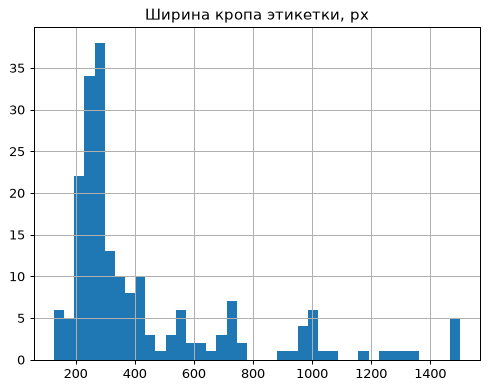

In [13]:
from wine_scanner.detect import CachedCropper
cropper = CachedCropper(cascade, Path("models/crop_cache"))

sample = catalog.sample(200, random_state=11)
records = []
for row in sample.itertuples(index=False):
    path = CATALOG / "images" / f"{row.slug}.png"
    image = load_image(path)
    crop = cropper(path, image)
    records.append({"slug": row.slug, "width": row.width, "crop_w": crop.width, "crop_h": crop.height,
                    "found": crop.size != image.size, "fill": (crop.width * crop.height) / (image.width * image.height)})
det = pd.DataFrame(records)
print(f"этикетка найдена на {det['found'].mean():.1%} карточек; медианный кроп {det['crop_w'].median():.0f}×{det['crop_h'].median():.0f} px")
print(f"кроп уже 150 px: {(det['crop_w'] < 150).sum()} из {len(det)}")
det["crop_w"].clip(upper=1500).hist(bins=40); plt.title("Ширина кропа этикетки, px"); plt.show()

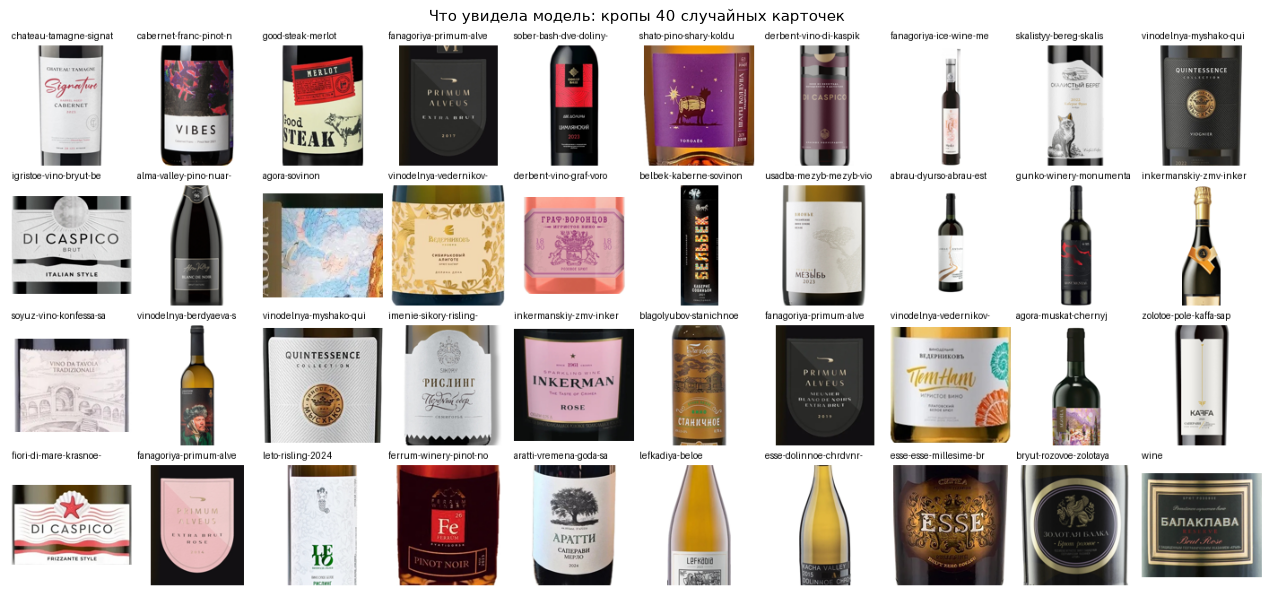

In [14]:
def sheet(items, columns=10, size=140):
    rows = (len(items) + columns - 1) // columns
    board = Image.new("RGB", (size * columns, (size + 16) * rows), "white"); draw = ImageDraw.Draw(board)
    for i, (caption, image) in enumerate(items):
        x, y = (i % columns) * size, (i // columns) * (size + 16)
        thumb = image.copy(); thumb.thumbnail((size - 6, size - 6))
        board.paste(thumb, (x + (size - thumb.width) // 2, y + 16 + (size - thumb.height) // 2))
        draw.text((x + 3, y + 2), caption[:22], fill="black")
    return board

tiles = [(r.slug, cropper(CATALOG / "images" / f"{r.slug}.png", load_image(CATALOG / "images" / f"{r.slug}.png")))
         for r in det.sample(40, random_state=3).itertuples()]
plt.figure(figsize=(18, 10)); plt.imshow(sheet(tiles)); plt.axis("off"); plt.title("Что увидела модель: кропы 40 случайных карточек");

## 7. Близнецы по картинке

Главный вопрос раздела: сколько в каталоге пар, которые DINOv2 не различает. Векторы берём из собранного
индекса `models/index_platform` — они посчитаны ровно той обрезкой и тем же режимом, что пойдут в сервис,
поэтому картина здесь совпадёт с тем, что увидит пайплайн. Считаем косинус каждой карточки к ближайшему
соседу и смотрим на хвост распределения.

векторов: 2103, размерность: 2048
карточек с соседом ближе 0.9: 1584 (75.3%)
карточек с соседом ближе 0.95: 981 (46.6%)
карточек с соседом ближе 0.98: 515 (24.5%)
медиана: 0.945


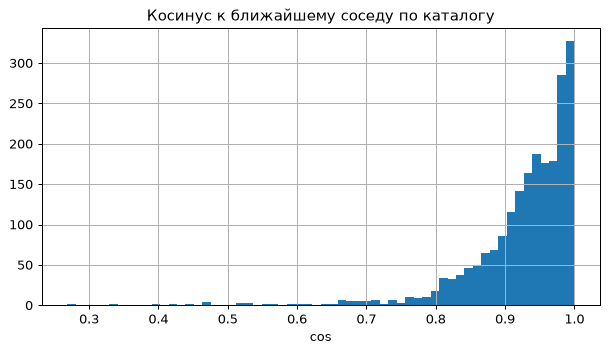

In [15]:
from wine_scanner.index import VectorIndex
INDEX = Path("models/index_platform")
assert (INDEX / "vectors.faiss").exists(), "сначала собрать индекс: build_index.py --catalog platform --out models/index_platform"
vindex = VectorIndex.load(INDEX)
V = vindex.index.reconstruct_n(0, vindex.index.ntotal)
ids = np.array(vindex.item_ids)
print(f"векторов: {V.shape[0]}, размерность: {V.shape[1]}")

S = V @ V.T
np.fill_diagonal(S, -1.0)
nn_sim = S.max(axis=1); nn_idx = S.argmax(axis=1)
neighbours = pd.DataFrame({"slug": ids, "nn_slug": ids[nn_idx], "nn_cos": nn_sim}).merge(
    catalog[["slug", "name", "winery", "vintage", "shared_image"]], on="slug")
neighbours = neighbours.merge(catalog[["slug", "name", "winery"]].rename(columns={"slug": "nn_slug", "name": "nn_name", "winery": "nn_winery"}), on="nn_slug")

plt.figure(figsize=(8, 4)); neighbours["nn_cos"].hist(bins=60); plt.title("Косинус к ближайшему соседу по каталогу"); plt.xlabel("cos")
for t in (0.9, 0.95, 0.98):
    print(f"карточек с соседом ближе {t}: {(neighbours['nn_cos'] > t).sum()} ({(neighbours['nn_cos'] > t).mean():.1%})")
print(f"медиана: {neighbours['nn_cos'].median():.3f}")

In [16]:
close = neighbours[neighbours["nn_cos"] > 0.95].copy()
close["same_winery"] = close["winery"] == close["nn_winery"]
close["same_name"] = close["name"].str.lower().str.replace(r"[,\s]*20[0-3]\d", "", regex=True).str.strip() == \
                     close["nn_name"].str.lower().str.replace(r"[,\s]*20[0-3]\d", "", regex=True).str.strip()
print("Среди пар ближе 0.95:")
print(f"  та же винодельня: {close['same_winery'].mean():.0%}")
print(f"  то же название (без года): {close['same_name'].mean():.0%}")
print(f"  одна и та же картинка: {close['shared_image'].mean():.0%}")
print("\nПримеры — та же винодельня, разное название (настоящие близнецы по дизайну):")
display(close[close["same_winery"] & ~close["same_name"]].sort_values("nn_cos", ascending=False)[["slug", "nn_slug", "nn_cos"]].head(15))

Среди пар ближе 0.95:
  та же винодельня: 97%
  то же название (без года): 5%
  одна и та же картинка: 6%

Примеры — та же винодельня, разное название (настоящие близнецы по дизайну):


,slug,nn_slug,nn_cos
377,method-classic-kokur,pino-nuar-2025,1.000001
1493,pino-nuar-2025,method-classic-kokur,1.000001
1545,rebo-rezerv,sand-zh-oveze-rezerv,1.000001
1722,sand-zh-oveze-rezerv,rebo-rezerv,1.000001
218,esse-demi-sec-muscat-nectar-muskat-belyy-beloe-ekstra-br...,esse-muskat-muskat-belyy-beloe-ekstra-bryut-115,1.000001
414,esse-muskat-muskat-belyy-beloe-ekstra-bryut-115,esse-demi-sec-muscat-nectar-muskat-belyy-beloe-ekstra-br...,1.000001
406,agrolayn-mountain-eagle-semillon-semilon-beloe-suhoe-11,agrolayn-mountain-eagle-traminer-traminer-beloe-suhoe-12,1.000000
407,agrolayn-mountain-eagle-traminer-traminer-beloe-suhoe-12,agrolayn-mountain-eagle-semillon-semilon-beloe-suhoe-11,1.000000
463,belmas-winery-pn-pino-nuar-krasnoe-suhoe-135,belmas-winery-vi-vione-beloe-suhoe-122,1.000000
596,belmas-winery-vi-vione-beloe-suhoe-122,belmas-winery-pn-pino-nuar-krasnoe-suhoe-135,1.000000


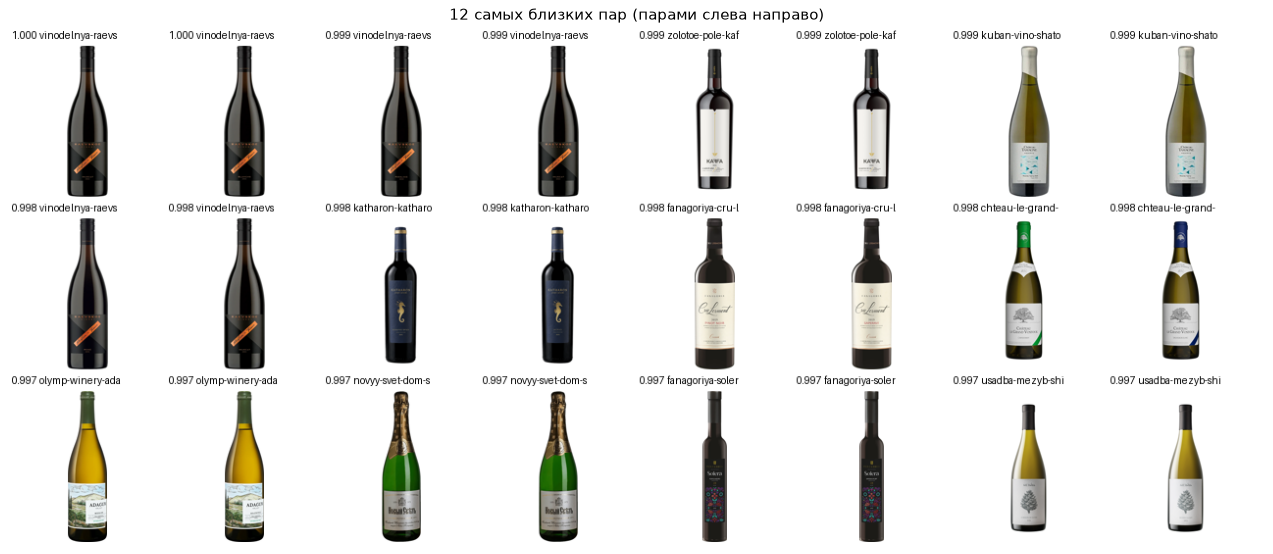

In [17]:
# Галерея самых близких пар: каждая пара один раз, без одинаковых файлов (те и так одинаковые).
pairs = []
seen = set()
for i in np.argsort(-nn_sim):
    j = nn_idx[i]
    key = tuple(sorted((i, j)))
    if key in seen or catalog.set_index("slug").loc[ids[i], "shared_image"]: continue
    seen.add(key); pairs.append((i, j, nn_sim[i]))
    if len(pairs) == 12: break
tiles = []
for i, j, s in pairs:
    for k in (i, j):
        tiles.append((f"{s:.3f} {ids[k]}", load_image(CATALOG / "images" / f"{ids[k]}.png")))
plt.figure(figsize=(18, 12)); plt.imshow(sheet(tiles, columns=8, size=160)); plt.axis("off"); plt.title("12 самых близких пар (парами слева направо)");

На этом хвосте и будет решаться контрольная оценка. Пара с косинусом 0.98 — это либо один и тот же файл,
либо этикетка, отличающаяся годом, объёмом или одним словом. Визуальный вектор их не разведёт; это работа
ре-ранкинга по локальным признакам, чтения года (Э8) и текстовой ветки — и именно на таких парах их надо
будет мерить, когда появятся свои полевые снимки российских вин.

Но медиана 0.945 к ближайшему соседу — это уже не про близнецов, а про **схлопнутое пространство**:
на белых вырезках DINOv2 видит в первую очередь «бутылку на белом», и все карточки оказываются рядом.
Отсюда и хаб — `aratti-vremena-goda-saperavi-vyderzhannyj-zima`, белая минималистичная этикетка,
к которой 353 карточки ближе 0.5 и которая попадает в топ-5 всех трёх запросов eval. Проверено на
готовых векторах: центрирование снижает долю соседей ближе 0.95 с 47 % до 24 %, PCA-whitening на 512
компонент — до 6 %. То есть Э5, отложенный до хакатона как «прирост съест ре-ранкинг», здесь нужен —
но, как показывает раздел 8, одного его мало.

## 8. Публичные кадры eval

Три кадра, снятые организаторами в магазине и дома. Смотрим, что на них, что вырезает детектор и есть ли
эти вина в дампе. Если индекс уже собран — сразу пять ближайших карточек к каждому кадру.

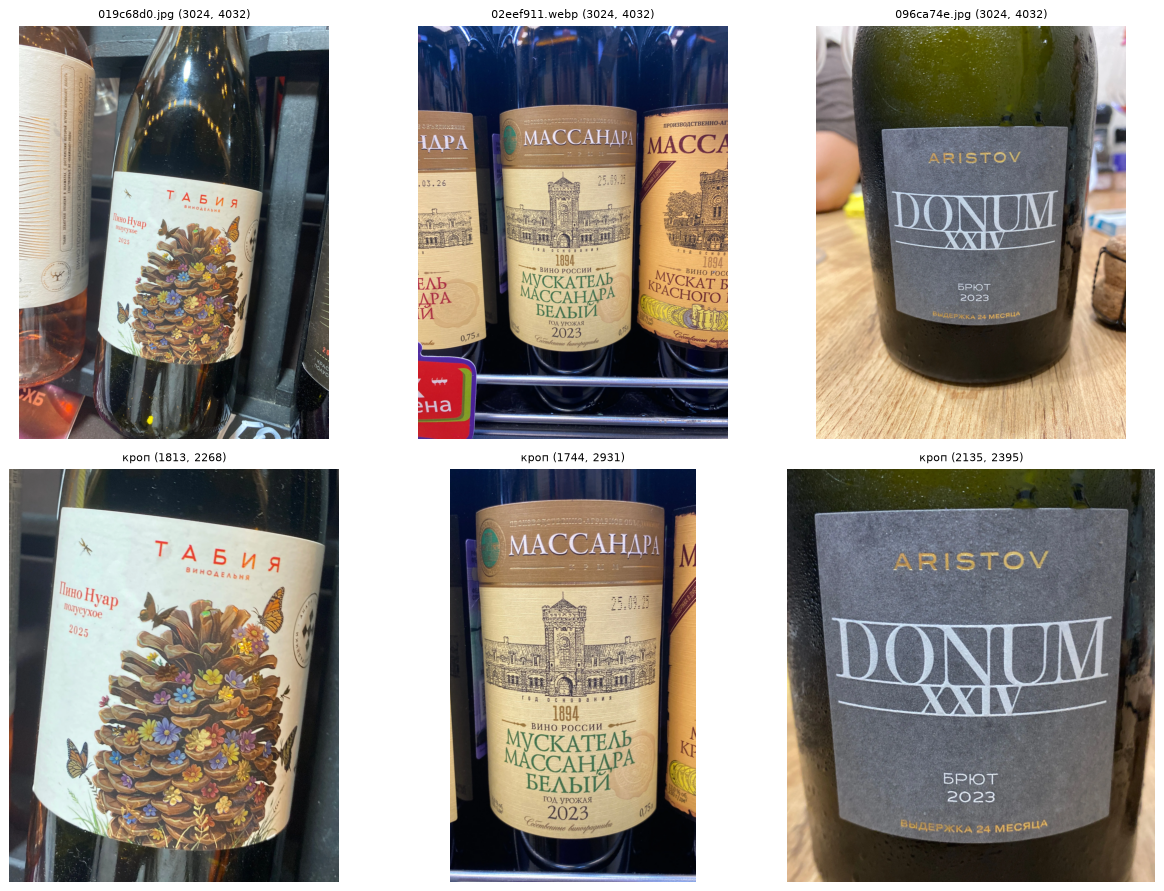

In [18]:
queries = load_eval_queries()
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for col, path in enumerate(queries):
    image = load_image(path); crop = cascade.crop(image)
    axes[0, col].imshow(image); axes[0, col].set_title(f"{path.name} {image.size}", fontsize=9); axes[0, col].axis("off")
    axes[1, col].imshow(crop); axes[1, col].set_title(f"кроп {crop.size}", fontsize=9); axes[1, col].axis("off")
plt.tight_layout()

In [19]:
def in_dump(*words):
    mask = np.ones(len(dump), dtype=bool)
    for w in words:
        mask &= (dump["name"] + " " + dump["winery"] + " " + dump["description"]).str.contains(w, case=False, regex=False).values
    return dump[mask][["slug", "name", "winery"]]

print("Кадр 1 — Табия, Пино Нуар полусухое 2025. Вина Табии в дампе:")
display(dump[dump["winery"].str.strip() == "Табия"][["slug", "name"]])
print("Кадр 2 — Aristov DONUM XXIV брют 2023. Поиск 'Donum' в дампе:", len(in_dump("donum")), "совпадений")
print("Кадр 3 — Мускатель Массандра белый:")
display(in_dump("Мускатель", "Массандра"))

Кадр 1 — Табия, Пино Нуар полусухое 2025. Вина Табии в дампе:


,slug,name
796,bukovinka,Буковинка
1052,kaberne-sovinon-2,Каберне Совиньон
1396,oleg,Олег
1501,pobeda,Победа
1605,risling-1,Рислинг
1656,roze-2,Розе
1679,rozovoe-zoloto,Розовое золото
1704,rubin-golodrigi,Рубин Голодриги
1945,czitronnyj-magaracha,Цитрон


Кадр 2 — Aristov DONUM XXIV брют 2023. Поиск 'Donum' в дампе: 0 совпадений
Кадр 3 — Мускатель Массандра белый:


,slug,name,winery
1359,massandra-muskatel-belyy-belye-sorta-vinograda-beloe-sla...,Мускатель белый,Массандра
1360,massandra-muskatel-rozovyy-belye-sorta-vinograda-rozovoe...,Мускатель розовый,Массандра
1361,massandra-muskatel-chernyy-krasnye-sorta-vinograda-krasn...,Мускатель черный,Массандра


In [20]:
if (INDEX / "vectors.faiss").exists():
    for path in queries:
        crop = cascade.crop(load_image(path))
        hits = vindex.search(embed(crop), top_k=5)
        print(f"\n{path.name}:")
        for h in hits:
            print(f"  {h.score:.3f}  {h.item_id[:60]:60s} {h.payload.get('winery', '')}")


019c68d0.jpg:
  0.627  aratti-vremena-goda-saperavi-vyderzhannyj-zima               АРАТТИ
  0.577  aratti-kaberne-sovinon-2020-krasnoe-suhoe                    АРАТТИ
  0.535  aratti-kaberne-sovinon-2021-krasnoe-suhoe                    АРАТТИ
  0.521  vinodelnya-molchanova-krasnostop-zolotovskiy-krasnoe-suhoe-1 Винодельня Молчанова
  0.515  artvin-kaberne-sovinon-grand-rezerv-krasnoe-suhoe-13         Артвин



02eef911.webp:
  0.645  massandra-kagor-gurzuf-saperavi-krasnoe-sladkoe-16           Массандра
  0.645  aratti-vremena-goda-saperavi-vyderzhannyj-zima               АРАТТИ
  0.639  massandra-portveyn-krasnyy-livadiya-kaberne-sovinon-krasnoe- Массандра
  0.623  aratti-kaberne-sovinon-2020-krasnoe-suhoe                    АРАТТИ
  0.580  twopeters_risling                                            Два Петра



096ca74e.jpg:
  0.714  aratti-vremena-goda-saperavi-vyderzhannyj-zima               АРАТТИ
  0.657  aratti-kaberne-sovinon-2021-krasnoe-suhoe                    АРАТТИ
  0.578  vinodelnya-raevskoe-renessans-karmener-krasnoe-suhoe-12      Раевское
  0.573  vinodelnya-raevskoe-renessans-blaufrankish-krasnoe-suhoe-128 Раевское
  0.565  vinodelnya-78-muskat-polusladkoe-muskat-ottonel-beloe-115    Винодельня 78


Два кадра из трёх — вина, которых в дампе от 07.09 нет. Это не ошибка сопоставления: у Табии в каталоге
девять вин и ни одного Пино Нуар, а Donum у Аристова не встречается ни в названиях, ни в описаниях.
Значит, проверка включает случай «вина нет в каталоге», и ТЗ на него отвечает прямо (п. 5): честно сказать
«не найдено» и показать похожие.

**Прогон `participant_test.sh` 16.09 на полном пайплайне: 0 из 3.** Все три кадра получили уверенный ответ
(0.83 / 0.79 / 0.94 при пороге 0.73) чужим slug; два из них — тем самым хабом АРАТТИ. Массандра — карточка
той же винодельни, но не та: визуальный ранг верной карточки **310**, при этом её эталон — 140 px шириной;
текстовая ветка узнала «МАССАНДРА», но «МУСКАТЕЛЬ» прочитан как «МУСКАТЕАЬ», и верная карточка в окно
кандидатов не попала вовсе. Ни центрирование, ни whitening ранг не спасают (лучшее — 146): проблема в самой
паре «телефонное фото ↔ крошечная вырезка». Задержка 6.9–9.6 с при лимите скрипта 10 с; из них ре-ранкинг
5.4 с и OCR 3.4 с на процессоре.

Решающий слой при этом обучен на своём наборе, где совпадение винодельни почти всегда означало верный
ответ, — здесь у одной винодельни десятки вин, и эта уверенность ничего не стоит.

## 9. Выводы

1. **Каталог собран полностью**: 2103 slug, у каждого эталон; 55 slug (27 групп) делят картинку байт в байт
   с другим slug — на них половина ответов будет мимо при любой модели, список в `catalog.csv` (`shared_image`).
2. **Эталон — студийная вырезка, часто крошечная**: медиана 336 px шириной, 893 карточки уже 300 px, 67 —
   уже 200. Детектор этикетку на них находит (96.5 %), медианный кроп 291×493, но у мелких карточек
   этикетка — 140 px, и это предел для любого эмбеддера.
3. **Пространство DINOv2 на этом каталоге схлопнуто**: медиана косинуса к соседу 0.945, у 47 % карточек
   сосед ближе 0.95, есть хаб, который тянет к себе всё. Whitening (Э5) снимает схлопнутость, но не домен.
4. **Полный пайплайн на публичном eval — 0 из 3, все три ответа уверенные.** Домен «телефон ↔ вырезка»
   не тот, на котором мерились 0.88 top-1: там эталоны были телефонными. Отказ не сработал ни разу —
   порог и признаки решающего слоя к этому каталогу не имеют отношения.
5. **Фон вырезки не важен** (разница в сотых), белый остаётся.
6. **Задержка 7–10 с на процессоре при лимите 10 с** у скрипта организаторов — на контрольном прогоне
   нужна видеокарта или окно ре-ранкинга меньше 25.

Что из этого следует для очереди работ — в CLAUDE.md, «Что дальше». Коротко: без своих полевых снимков
вин из этого каталога ни один из пунктов не измерить, поэтому съёмка — первая; за ней дообучение
эмбеддера под пару «фото ↔ вырезка» (Э9, синтетика из каталога) или SigLIP 2 из рекомендаций ТЗ как
второй кандидат в тот же замер; whitening — дёшево и сразу; OCR-ветке нужна устойчивость к «Л→А».

In [21]:
summary = {
    "slug в каталоге": len(catalog),
    "с картинкой": int(catalog["source_file"].notna().sum()),
    "slug с годом": int(catalog["vintage"].notna().sum()),
    "slug с общей картинкой (по хэшу)": int(catalog["shared_image"].sum()),
    "эталон уже 300 px": int((catalog["width"] <= 300).sum()),
    "детектор нашёл этикетку (выборка 200)": f"{det['found'].mean():.1%}",
    "медианный кроп этикетки, px": f"{det['crop_w'].median():.0f}×{det['crop_h'].median():.0f}",
    "сосед ближе 0.95": int((neighbours["nn_cos"] > 0.95).sum()),
    "сосед ближе 0.98": int((neighbours["nn_cos"] > 0.98).sum()),
}
pd.Series(summary).to_frame("значение")

,значение
slug в каталоге,2103
с картинкой,2103
slug с годом,116
slug с общей картинкой (по хэшу),55
эталон уже 300 px,893
детектор нашёл этикетку (выборка 200),96.5%
"медианный кроп этикетки, px",291×493
сосед ближе 0.95,981
сосед ближе 0.98,515
